In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense


E:\anaconda\envs\pytorchp\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [2]:
data = pd.read_csv("sample_data.csv", header=None)

In [3]:
data.head()

,0,1,2,3,4,5
0,04/24/2020,1279.31,1640394,1261.17,1280.4000,1249.45
1,04/23/2020,1276.31,1566203,1271.55,1293.3100,1265.67
2,04/22/2020,1263.21,2093140,1245.54,1285.6133,1242.00
3,04/21/2020,1216.34,2153003,1247.00,1254.2700,1209.71
4,04/20/2020,1266.61,1695488,1271.00,1281.6000,1261.37


In [4]:
data.describe()

,1,2,3,4,5
count,1259.000000,1.259000e+03,1259.000000,1259.000000,1259.000000
mean,962.947577,1.714574e+06,962.477052,971.246177,953.832749
std,232.519209,8.583264e+05,231.963050,234.627962,229.886438
min,516.830000,3.475180e+05,519.500000,522.734000,515.180000
25%,759.400000,1.205744e+06,758.585000,767.020000,752.000000
50%,988.200000,1.487378e+06,989.440000,994.120000,980.640000
75%,1146.585000,1.964392e+06,1144.225000,1155.675000,1133.155000
max,1526.690000,1.115350e+07,1525.070000,1532.106300,1521.400000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1259 non-null   str    
 1   1       1259 non-null   float64
 2   2       1259 non-null   int64  
 3   3       1259 non-null   float64
 4   4       1259 non-null   float64
 5   5       1259 non-null   float64
dtypes: float64(4), int64(1), str(1)
memory usage: 59.1 KB


In [6]:
len_data = data.shape[:1][0]
len_data

1259

In [7]:
actual_data = data.iloc[:, 1:2]
type(actual_data)

pandas.DataFrame

In [8]:
print(actual_data[:5])
actual_data = actual_data.to_numpy()

         1
0  1279.31
1  1276.31
2  1263.21
3  1216.34
4  1266.61


In [9]:
actual_data = actual_data.reshape(len_data, 1)

In [10]:
actual_data.shape

(1259, 1)

In [11]:
actual_data[:5]

array([[1279.31],
       [1276.31],
       [1263.21],
       [1216.34],
       [1266.61]])

In [12]:
scaler = MinMaxScaler()
actual_data = scaler.fit_transform(actual_data)
actual_data[:5]

array([[0.75503535],
       [0.75206464],
       [0.73909255],
       [0.69268017],
       [0.74245935]])

In [13]:
actual_data.shape

(1259, 1)

In [14]:
look_back = 10
forward_days = 5
period = 20
# 1259 - 20 * 20 = 1059
division = len_data - period * look_back

In [15]:
train_data = actual_data[:division] # 1059
# division - look_back = 1059 - 10 = 1049 overlap 10
test_data = actual_data[division - look_back :]
train_x,  train_y = [], []
test_x,  test_y = [], []

In [16]:
# len(train_data) = 1059,  forward_days = 5, look_back = 10
for i in range(len(train_data) - forward_days - look_back + 1): # 1059 - 5 - 10 + 1 = 1045
    #tx[0] = td[0: 10], tx[1] = td[1:11]....
    train_x.append(train_data[i : i + look_back])
    # ty[0] = td[10:15] ty[1] = td[11:16]....
    train_y.append(train_data[i + look_back : i + look_back + forward_days])
for i in range(len(test_data) - forward_days - look_back + 1): # 210-5-10+1=196
    #tx[0] = td[0:10] tx[1] = [11:20]
    test_x.append(test_data[i : i + look_back])
    # 5
    test_y.append(test_data[i + look_back : i + look_back + forward_days])

time series：
time:  t0  t1  t2  t3  t4  t5  t6  t7  t8  t9 t10 t11 t12 t13 t14
data:  [d0, d1, d2, d3, d4, d5, d6, d7, d8, d9,d10,d11,d12,d13,d14]

sample1: X=[d0-d9], Y=[d10-d14]
sample2: X=[d1-d10], Y=[d11-d15]
sample3: X=[d2-d11], Y=[d12-d16]
...


train_y[0] = [[0.123],
              [0.456],
              [0.789],
              [0.234],
              [0.567]]
# shape: (5, 1)
train_y[0].ravel() = [0.123, 0.456, 0.789, 0.234, 0.567]
# shape: (5,)
list(train_y[0].ravel()) = [0.123, 0.456, 0.789, 0.234, 0.567]
# Python list
[
    [0.123, 0.456, 0.789, 0.234, 0.567],  # train_y[0]
    [0.678, 0.901, 0.345, 0.678, 0.901],  # train_y[1]
    [0.234, 0.567, 0.890, 0.123, 0.456],  # train_y[2]
    ...
]

train_y = [
    [[val1], [val2], [val3], [val4], [val5]],  # 样本 0
    [[val1], [val2], [val3], [val4], [val5]],  # 样本 1
    ...
]

# 如果转成 numpy 数组，shape = (1045, 5, 1)
y_train = [
    [val1, val2, val3, val4, val5],  # 样本 0
    [val1, val2, val3, val4, val5],  # 样本 1
    ...
]

# shape = (1045, 5)

or
y_train = np.array([list(i.ravel()) for i in train_y])
y_train = np.array([i.ravel() for i in train_y])
y_train = np.array(train_y).reshape(-1, forward_days)
y_train = np.array(train_y).squeeze(axis=2)
y_train = np.array([list(i.flatten()) for i in train_y])



In [17]:
# train_x -> (1045, 10, 1) -> 1045 samples, 10 steps, every step 1 feature
# train_y.shape = (1045, 5)
x_train = np.array(train_x)
x_test = np.array(test_x)
print(x_train.shape), print(x_test.shape)
# 3d(sample, time step,feature) -> 2d(sample, time step)
y_train = np.array([list(i.ravel()) for i in train_y])
y_test = np.array([list(i.ravel()) for i in test_y])
print(y_train.shape)

(1045, 10, 1)
(196, 10, 1)
(1045, 5)


方法	返回值	内存
ravel()	视图（可能）	更少
flatten()	总是副本	稍多
视图 vs 副本
1. 视图
定义：视图是原数组的一个"窗口"，它共享原数组的内存空间。

特点：

修改视图会影响原数组
修改原数组会影响视图
不占用额外内存
快速创建
内存: [1 | 99 | 3 | 4 | 5]
       ↑   ↑   ↑   ↑
       │   │   │   │
       │   │   └───┘── 视图 view 指向这些位置
       │   └─── 原数组 arr 也指向这些位置
       └───── 原数组 arr 指向整个内存块
2. 副本
定义：副本是原数组的独立拷贝，拥有自己的内存空间。

特点：

修改副本不会影响原数组
修改原数组不会影响副本
占用额外内存
需要复制数据，稍慢
原数组内存: [1 | 2 | 3 | 4 | 5]
                ↑   ↑   ↑   ↑
                │   │   │   │
                └───└───┴───┘── 原数组 arr

副本内存:   [99 | 3 | 4]
                ↑   ↑   ↑
                │   │   │
                └───┴───┘── 副本 copy (独立内存)


In [18]:
model = Sequential()

为什么 return_sequences=True？

当有多层 LSTM 时，第一层需要返回完整序列给下一层
如果是单层 LSTM，应该设为 False（默认值）

In [19]:
#隐藏层有 128 个 LSTM 单元, (10, 1) - 10 个时间步，每步 1 个特征, 返回所有时间步的输出（不仅是最后一个）
model.add(LSTM(128, input_shape=(look_back, 1), return_sequences=True))
model.add(LSTM(64))
# forward_days	输出维度	5 - 预测未来 5 天的数据
model.add(Dense(forward_days))
model.compile(loss="mean_squared_error", optimizer="adam")
# verbose=1	显示进度	显示训练进度条
# 批次数量 = 样本总数 / batch_size = 1045 / 4 ≈ 262
history = model.fit(
    x_train, y_train, epochs=10, verbose=1, shuffle=True, batch_size=4
)
pred = model.predict(x_test)

E:\anaconda\envs\pytorchp\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0109
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0023
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0021
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0021
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0019
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0017
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0017
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016
Epoch 9/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016
Epoch 10/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0014
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


In [20]:
pred

array([[0.17526457, 0.17436117, 0.17863783, 0.17344114, 0.18026231],
       [0.1722255 , 0.17128216, 0.17541876, 0.17032848, 0.1771583 ],
       [0.17028883, 0.1693661 , 0.17330019, 0.1683403 , 0.17517005],
       [0.1690984 , 0.16813955, 0.17199863, 0.16708222, 0.17384844],
       [0.17202646, 0.17124961, 0.17491579, 0.17004514, 0.17671548],
       [0.17911524, 0.17862187, 0.18215615, 0.17725319, 0.18380772],
       [0.19239824, 0.19228439, 0.19588469, 0.19075513, 0.19712391],
       [0.2048643 , 0.20486073, 0.20892768, 0.20342708, 0.20973876],
       [0.21358375, 0.21348496, 0.21824384, 0.21231988, 0.21866821],
       [0.21730743, 0.21704364, 0.22246249, 0.21617463, 0.22260927],
       [0.21362272, 0.21310876, 0.21902254, 0.21253344, 0.21912278],
       [0.20941044, 0.20901209, 0.21476735, 0.20840576, 0.21521154],
       [0.20543876, 0.20532207, 0.21053497, 0.20450161, 0.21152219],
       [0.20441528, 0.20474096, 0.20914687, 0.20357108, 0.21078682],
       [0.20194218, 0.20237939, 0.

In [21]:
y_test

array([[0.15970531, 0.1642901 , 0.165112  , 0.18931337, 0.20806845],
       [0.1642901 , 0.165112  , 0.18931337, 0.20806845, 0.24540035],
       [0.165112  , 0.18931337, 0.20806845, 0.24540035, 0.23287386],
       [0.18931337, 0.20806845, 0.24540035, 0.23287386, 0.22391223],
       [0.20806845, 0.24540035, 0.23287386, 0.22391223, 0.21203929],
       [0.24540035, 0.23287386, 0.22391223, 0.21203929, 0.18137168],
       [0.23287386, 0.22391223, 0.21203929, 0.18137168, 0.19429426],
       [0.22391223, 0.21203929, 0.18137168, 0.19429426, 0.19293763],
       [0.21203929, 0.18137168, 0.19429426, 0.19293763, 0.20638504],
       [0.18137168, 0.19429426, 0.19293763, 0.20638504, 0.18790723],
       [0.19429426, 0.19293763, 0.20638504, 0.18790723, 0.17984671],
       [0.19293763, 0.20638504, 0.18790723, 0.17984671, 0.1831541 ],
       [0.20638504, 0.18790723, 0.17984671, 0.1831541 , 0.17588577],
       [0.18790723, 0.17984671, 0.1831541 , 0.17588577, 0.19595786],
       [0.17984671, 0.1831541 , 0.

# 保存原始的 scaler（需要在数据预处理时保存）
# scaler = MinMaxScaler()
# actual_data = scaler.fit_transform(actual_data)

# 反归一化预测值
pred_original = scaler.inverse_transform(pred)
pred_original = pred_original.reshape(-1, 5)  # 确保形状正确

In [22]:
pred_original = scaler.inverse_transform(pred)
pred_original = pred_original.reshape(-1,5)
print(pred_original[:5])
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1,5)

[[693.8227  692.9104  697.2292  691.98126 698.8697 ]
 [690.75366 689.80096 693.9784  688.8379  695.7351 ]
 [688.79785 687.866   691.8389  686.83014 693.72723]
 [687.5957  686.6274  690.52454 685.55963 692.3926 ]
 [690.5527  689.7681  693.47046 688.5518  695.2879 ]]


In [23]:
print(y_test_original)

[[678.11 682.74 683.57 708.01 726.95]
 [682.74 683.57 708.01 726.95 764.65]
 [683.57 708.01 726.95 764.65 752.  ]
 [708.01 726.95 764.65 752.   742.95]
 [726.95 764.65 752.   742.95 730.96]
 [764.65 752.   742.95 730.96 699.99]
 [752.   742.95 730.96 699.99 713.04]
 [742.95 730.96 699.99 713.04 711.67]
 [730.96 699.99 713.04 711.67 725.25]
 [699.99 713.04 711.67 725.25 706.59]
 [713.04 711.67 725.25 706.59 698.45]
 [711.67 725.25 706.59 698.45 701.79]
 [725.25 706.59 698.45 701.79 694.45]
 [706.59 698.45 701.79 694.45 714.72]
 [698.45 701.79 694.45 714.72 700.56]
 [701.79 694.45 714.72 700.56 726.07]
 [694.45 714.72 700.56 726.07 716.03]
 [714.72 700.56 726.07 716.03 714.47]
 [700.56 726.07 716.03 714.47 726.39]
 [726.07 716.03 714.47 726.39 743.62]
 [716.03 714.47 726.39 743.62 742.58]
 [714.47 726.39 743.62 742.58 741.84]
 [726.39 743.62 742.58 741.84 758.88]
 [743.62 742.58 741.84 758.88 771.  ]
 [742.58 741.84 758.88 771.   776.6 ]
 [741.84 758.88 771.   776.6  762.51]
 [758.88 771

In [24]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(pred, y_test)
mseo = mean_squared_error(pred_original, y_test_original)
mse,  mseo

(0.0008020881265271542, 817.983318475133)

In [25]:
rmse = np.sqrt(mse)
rmseo = np.sqrt(mseo)
rmse, rmseo

(np.float64(0.028321160402200226), np.float64(28.600407662743777))

In [26]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(pred, y_test)
maeo = mean_absolute_error(pred_original, y_test_original)
mae, maeo

(0.020081440179560078, 20.27944343411193)

In [27]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [28]:
sc = mean_absolute_percentage_error(y_test, pred)

C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\827515385.py:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [29]:
sc = mean_absolute_percentage_error(y_test_original, pred_original)
sc


np.float64(3.224072376694995)

In [30]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred)
r2o = r2_score(y_test_original, pred_original)
r2, r2o

(0.878196216614518, 0.8781962112955128)

In [31]:
def direction_accuracy(y_true, y_pred):
    """
    计算预测方向是否正确（上涨/下跌）
    """
    # 对于多步预测，我们只预测第1天的方向
    y_true_direction = np.sign(np.diff(y_true[:, 0]))
    y_pred_direction = np.sign(np.diff(y_pred[:, 0]))

    # 计算准确率
    accuracy = np.mean(y_true_direction == y_pred_direction) * 100
    return accuracy

dir_acc = direction_accuracy(y_test_original, pred_original)
print(f"方向准确率: {dir_acc:.2f}%")

方向准确率: 45.64%


In [32]:
def up_down_accuracy(y_true, y_pred, threshold=0):
    """
    计算涨跌预测准确率
    threshold: 涨跌的阈值（默认0）
    """
    # 判断实际涨跌
    actual_change = np.sign(np.diff(y_true[:, 0]) - threshold)

    # 判断预测涨跌
    pred_change = np.sign(np.diff(y_pred[:, 0]) - threshold)

    # 计算准确率
    accuracy = np.mean(actual_change == pred_change) * 100
    return accuracy

up_down_acc = up_down_accuracy(y_test_original, pred_original, threshold=0)
print(f"涨跌准确率: {up_down_acc:.2f}%")


涨跌准确率: 45.64%


In [33]:
def evaluate_model(y_true, y_pred, scaler=None):
    """
    完整的模型评估函数

    参数:
        y_true: 真实值（归一化或原始尺度）
        y_pred: 预测值（归一化或原始尺度）
        scaler: MinMaxScaler 对象（用于反归一化）

    返回:
        metrics: 包含所有评估指标的字典
    """
    metrics = {}

    # 反归一化（如果提供了scaler）
    if scaler is not None:
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(-1, 5)
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1, 5)

    # 计算指标
    metrics['MSE'] = mean_squared_error(y_true, y_pred)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['MAPE'] = mean_absolute_percentage_error(y_true, y_pred)
    metrics['R²'] = r2_score(y_true, y_pred)
    metrics['Direction_Accuracy'] = direction_accuracy(y_true, y_pred)
    metrics['Up_Down_Accuracy'] = up_down_accuracy(y_true, y_pred)

    return metrics

# 使用评估函数
metrics = evaluate_model(y_test, pred, scaler)

# 打印所有指标
print("="*50)
print("模型评估指标")
print("="*50)
for metric, value in metrics.items():
    if metric in ['MAPE', 'Direction_Accuracy', 'Up_Down_Accuracy']:
        print(f"{metric:25s}: {value:.2f}%")
    else:
        print(f"{metric:25s}: {value:.4f}")
print("="*50)


模型评估指标
MSE                      : 817.9833
RMSE                     : 28.6004
MAE                      : 20.2794
MAPE                     : 3.22%
R²                       : 0.8782
Direction_Accuracy       : 45.64%
Up_Down_Accuracy         : 45.64%


E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  f

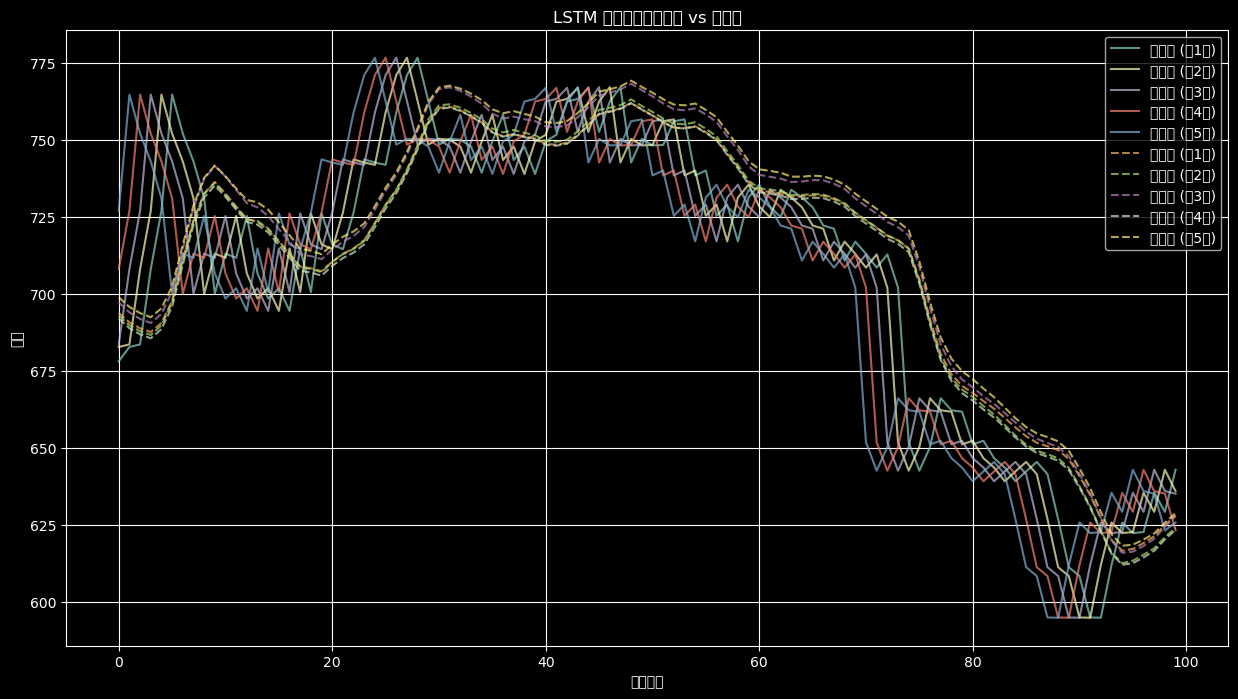

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# 只显示前 100 个样本以保持清晰
n_samples = min(100, len(y_test_original))

# 绘制真实值
for i in range(5):  # 5 个预测天
    plt.plot(range(n_samples), y_test_original[:n_samples, i],
             label=f'真实值 (第{i+1}天)', alpha=0.7)

# 绘制预测值
for i in range(5):
    plt.plot(range(n_samples), pred_original[:n_samples, i],
             label=f'预测值 (第{i+1}天)', linestyle='--', alpha=0.7)

plt.xlabel('样本索引')
plt.ylabel('股价')
plt.title('LSTM 股价预测：真实值 vs 预测值')
plt.legend()
plt.grid(True)
plt.show()


E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaV

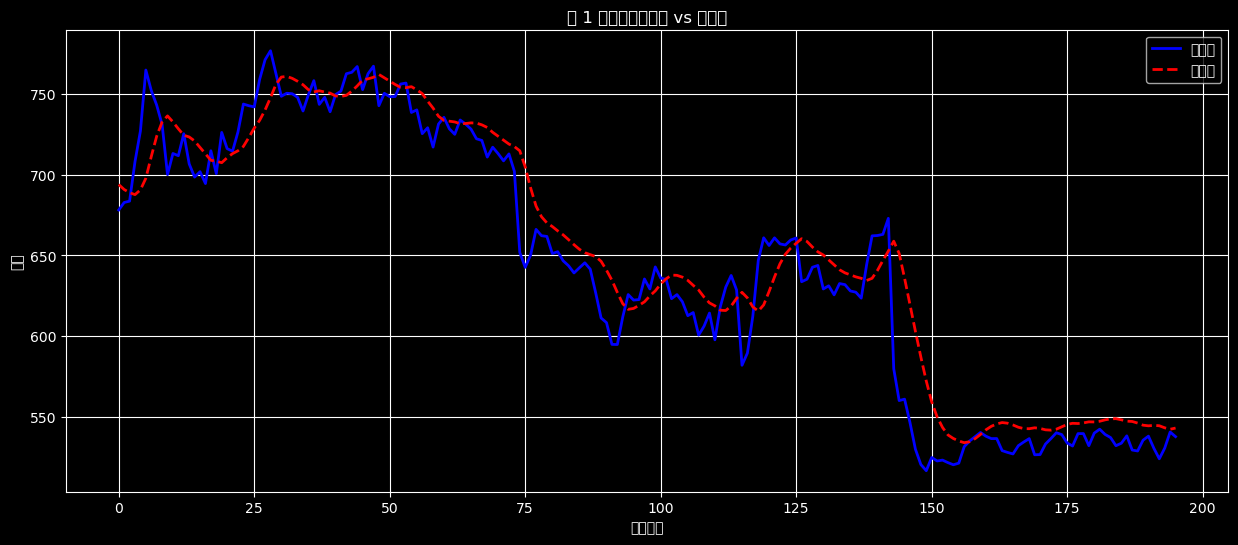

In [35]:
plt.figure(figsize=(15, 6))

plt.plot(y_test_original[:, 0], label='真实值', color='blue', linewidth=2)
plt.plot(pred_original[:, 0], label='预测值', color='red', linewidth=2, linestyle='--')

plt.xlabel('样本索引')
plt.ylabel('股价')
plt.title('第 1 天预测：真实值 vs 预测值')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\2328044834.py:45: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\2328044834.py:45: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\2328044834.py:45: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\2328044834.py:45: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\2328044834.py:45: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mingw\AppData\Local\Temp\ipykernel_16256\2328044834.py:45: UserWarning: Glyph 24067 (\

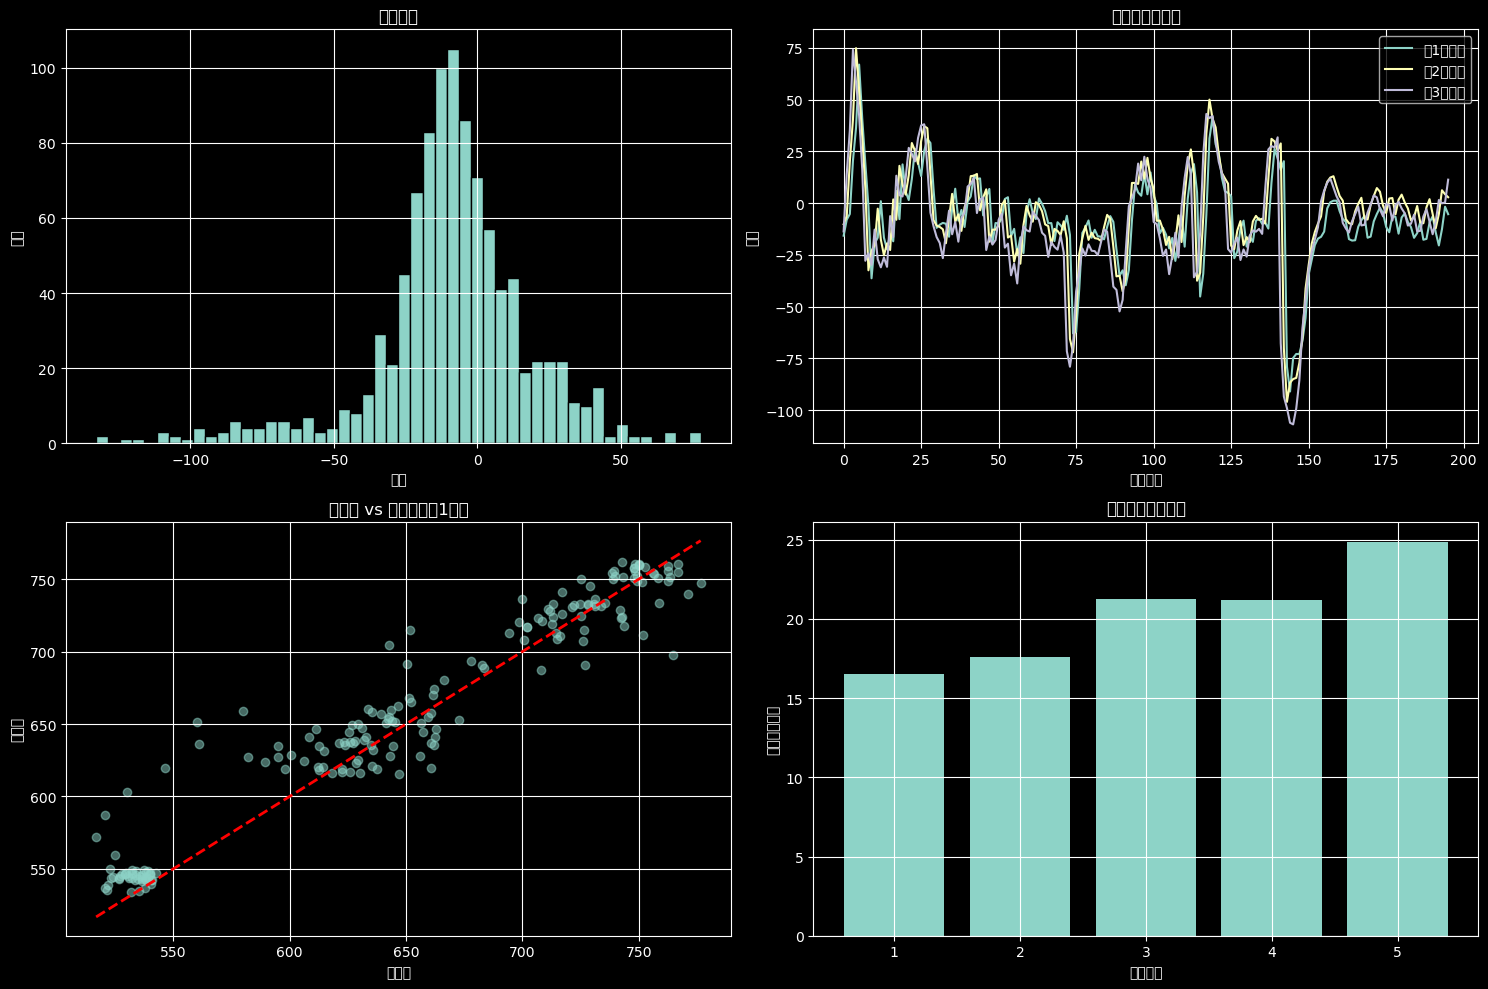

In [36]:
# 计算误差
errors = y_test_original - pred_original

plt.figure(figsize=(15, 10))

# 误差直方图
plt.subplot(2, 2, 1)
plt.hist(errors.flatten(), bins=50, edgecolor='black')
plt.xlabel('误差')
plt.ylabel('频数')
plt.title('误差分布')
plt.grid(True)

# 误差随时间变化
plt.subplot(2, 2, 2)
plt.plot(errors[:, 0], label='第1天误差')
plt.plot(errors[:, 1], label='第2天误差')
plt.plot(errors[:, 2], label='第3天误差')
plt.xlabel('样本索引')
plt.ylabel('误差')
plt.title('误差随时间变化')
plt.legend()
plt.grid(True)

# 真实值 vs 预测值散点图
plt.subplot(2, 2, 3)
plt.scatter(y_test_original[:, 0], pred_original[:, 0], alpha=0.5)
plt.plot([y_test_original[:, 0].min(), y_test_original[:, 0].max()],
         [y_test_original[:, 0].min(), y_test_original[:, 0].max()],
         'r--', lw=2)
plt.xlabel('真实值')
plt.ylabel('预测值')
plt.title('真实值 vs 预测值（第1天）')
plt.grid(True)

# 每日平均误差
plt.subplot(2, 2, 4)
daily_mae = np.mean(np.abs(errors), axis=0)
plt.bar(range(1, 6), daily_mae)
plt.xlabel('预测天数')
plt.ylabel('平均绝对误差')
plt.title('每日平均绝对误差')
plt.grid(True)

plt.tight_layout()
plt.show()


In [37]:
def daily_metrics(y_true, y_pred):
    """
    计算每天的预测指标
    """
    daily_results = []

    for day in range(y_true.shape[1]):
        y_true_day = y_true[:, day]
        y_pred_day = y_pred[:, day]

        metrics = {
            'day': day + 1,
            'MSE': mean_squared_error(y_true_day, y_pred_day),
            'RMSE': np.sqrt(mean_squared_error(y_true_day, y_pred_day)),
            'MAE': mean_absolute_error(y_true_day, y_pred_day),
            'MAPE': mean_absolute_percentage_error(y_true_day, y_pred_day)
        }
        daily_results.append(metrics)

    return daily_results

# 计算每日指标
daily_metrics_results = daily_metrics(y_test_original, pred_original)

# 打印每日指标
print("\n每日预测指标:")
print("="*60)
print(f"{'天数':<6} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'MAPE':<10}")
print("-"*60)
for metrics in daily_metrics_results:
    print(f"{metrics['day']:<6} {metrics['MSE']:<12.2f} "
          f"{metrics['RMSE']:<12.2f} {metrics['MAE']:<12.2f} "
          f"{metrics['MAPE']:<10.2f}%")
print("="*60)



每日预测指标:
天数     MSE          RMSE         MAE          MAPE      
------------------------------------------------------------
1      517.63       22.75        16.51        2.65      %
2      626.78       25.04        17.60        2.78      %
3      855.96       29.26        21.23        3.36      %
4      910.27       30.17        21.18        3.36      %
5      1179.28      34.34        24.88        3.97      %



模型评估:
MSE                      : 817.9833
RMSE                     : 28.6004
MAE                      : 20.2794
MAPE                     : 3.22%
R²                       : 0.8782
Direction_Accuracy       : 45.64%
Up_Down_Accuracy         : 45.64%

每日预测指标:
第 1 天 - MAE: 16.51, MAPE: 2.65%
第 2 天 - MAE: 17.60, MAPE: 2.78%
第 3 天 - MAE: 21.23, MAPE: 3.36%
第 4 天 - MAE: 21.18, MAPE: 3.36%
第 5 天 - MAE: 24.88, MAPE: 3.97%


E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorchp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaV

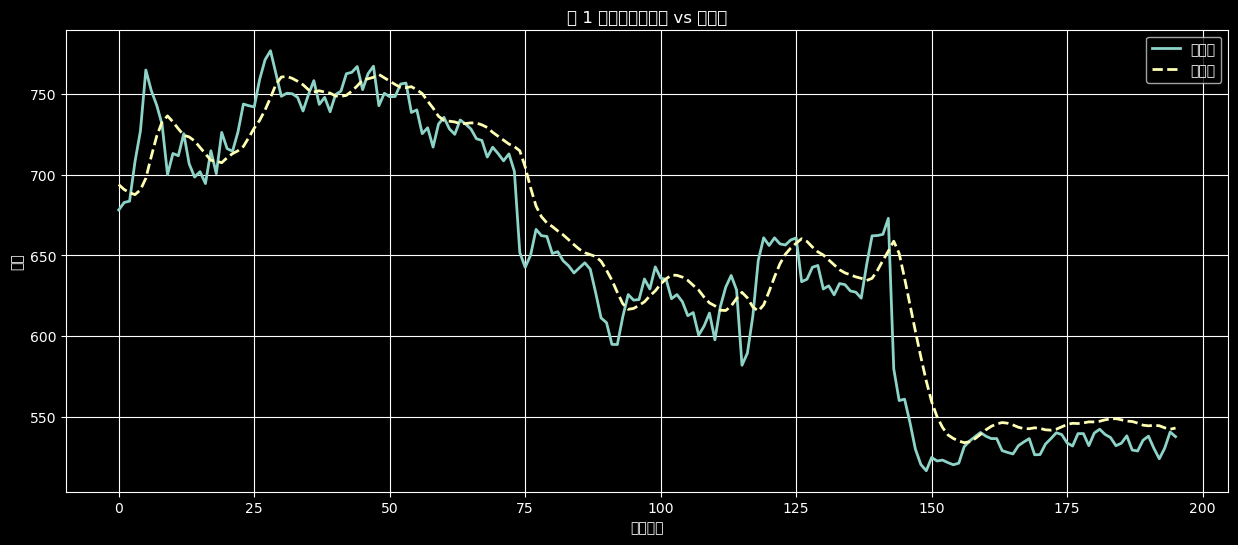

In [38]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 假设 pred 和 y_test 已经得到
# pred = model.predict(x_test)  # 形状: (196, 5)

# 2. 反归一化
pred_original = scaler.inverse_transform(pred)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, 5)

# 3. 计算所有指标
metrics = evaluate_model(y_test, pred, scaler)

# 4. 打印指标
print("\n模型评估:")
for metric, value in metrics.items():
    if metric in ['MAPE', 'Direction_Accuracy', 'Up_Down_Accuracy']:
        print(f"{metric:25s}: {value:.2f}%")
    else:
        print(f"{metric:25s}: {value:.4f}")

# 5. 每日指标
print("\n每日预测指标:")
daily_metrics_results = daily_metrics(y_test_original, pred_original)
for metrics in daily_metrics_results:
    print(f"第 {metrics['day']} 天 - MAE: {metrics['MAE']:.2f}, MAPE: {metrics['MAPE']:.2f}%")

# 6. 可视化
plt.figure(figsize=(15, 6))
plt.plot(y_test_original[:, 0], label='真实值', linewidth=2)
plt.plot(pred_original[:, 0], label='预测值', linewidth=2, linestyle='--')
plt.xlabel('样本索引')
plt.ylabel('股价')
plt.title('第 1 天预测：真实值 vs 预测值')
plt.legend()
plt.grid(True)
plt.show()
